In [1]:
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import hygeia.utils.hplots as hp
import compute_multi_perts_liver as mtp
import metrics_tools as mt

In [3]:
methods = ['SCDISENTANGLE', 'BIOLORD', 'SCDISINFACT', 'CPA', 'context-agnostic', 'perturbation-agnostic']
data_name = 'Liver_HPI'
cov_key = 'zone'
cond_key = 'coarse_time'
control_name = 'Control'
degs_key = 'rank_genes_groups_infection_hpi_specific'
pert_names = [
    '2 hpi', '12 hpi', '24 hpi', '30 hpi', '36 hpi',
]
cov_names = ['Periportal', 'Pericentral']
seeds = list(range(1, 11))

# Compute metrics

### can be skipped if results already exported

In [ ]:
adata_original = sc.read_h5ad('../../Datasets/preprocessed_datasets/liver.h5ad')

In [ ]:
for method_name in methods:
    for ood_cov in cov_names:
        train_median = np.median(
            adata_original[adata_original.obs[f'split_Infected_{ood_cov}'] == 'train'
        ].X.sum(axis=1)
                                )
        
        for seed_nb in seeds:
            if method_name in ['context-agnostic', 'perturbation-agnostic']:
                adata_predicted=None
            else:
                adata_predicted = sc.read_h5ad(
                    f'../{method_name}/{data_name}/predictions/{ood_cov}_{seed_nb}.h5ad'
                )
            mtp.compute_metrics(
                data_name=data_name,
                method_name=method_name,
                seed_nb=seed_nb,
                adata_original=adata_original[adata_original.obs['status_control'] != 'Uninfected'],
                adata_predicted=adata_predicted,
                cov_key=cov_key,
                cond_key=cond_key,
                ood_cov=ood_cov,
                control_name=control_name,
                pert_names=pert_names,
                degs_key = degs_key,
                _train_median=train_median,
        )

# Plot

In [4]:
data_name = 'Liver_HPI'

pert_names = [
    '2 hpi', '12 hpi', '24 hpi', '30 hpi', '36 hpi',
]

all_results = []
for seed_nb in seeds:
    for ood_cov in cov_names:
        for pert_name in pert_names:
            all_results.append(f'{ood_cov}_{pert_name}_{seed_nb}')

In [5]:
base_path = f'results/{data_name}'

In [6]:
os.makedirs(f'{FIG_ROOT}/{data_name}/Benchmarks/', exist_ok=True)

Using 100 perturbation


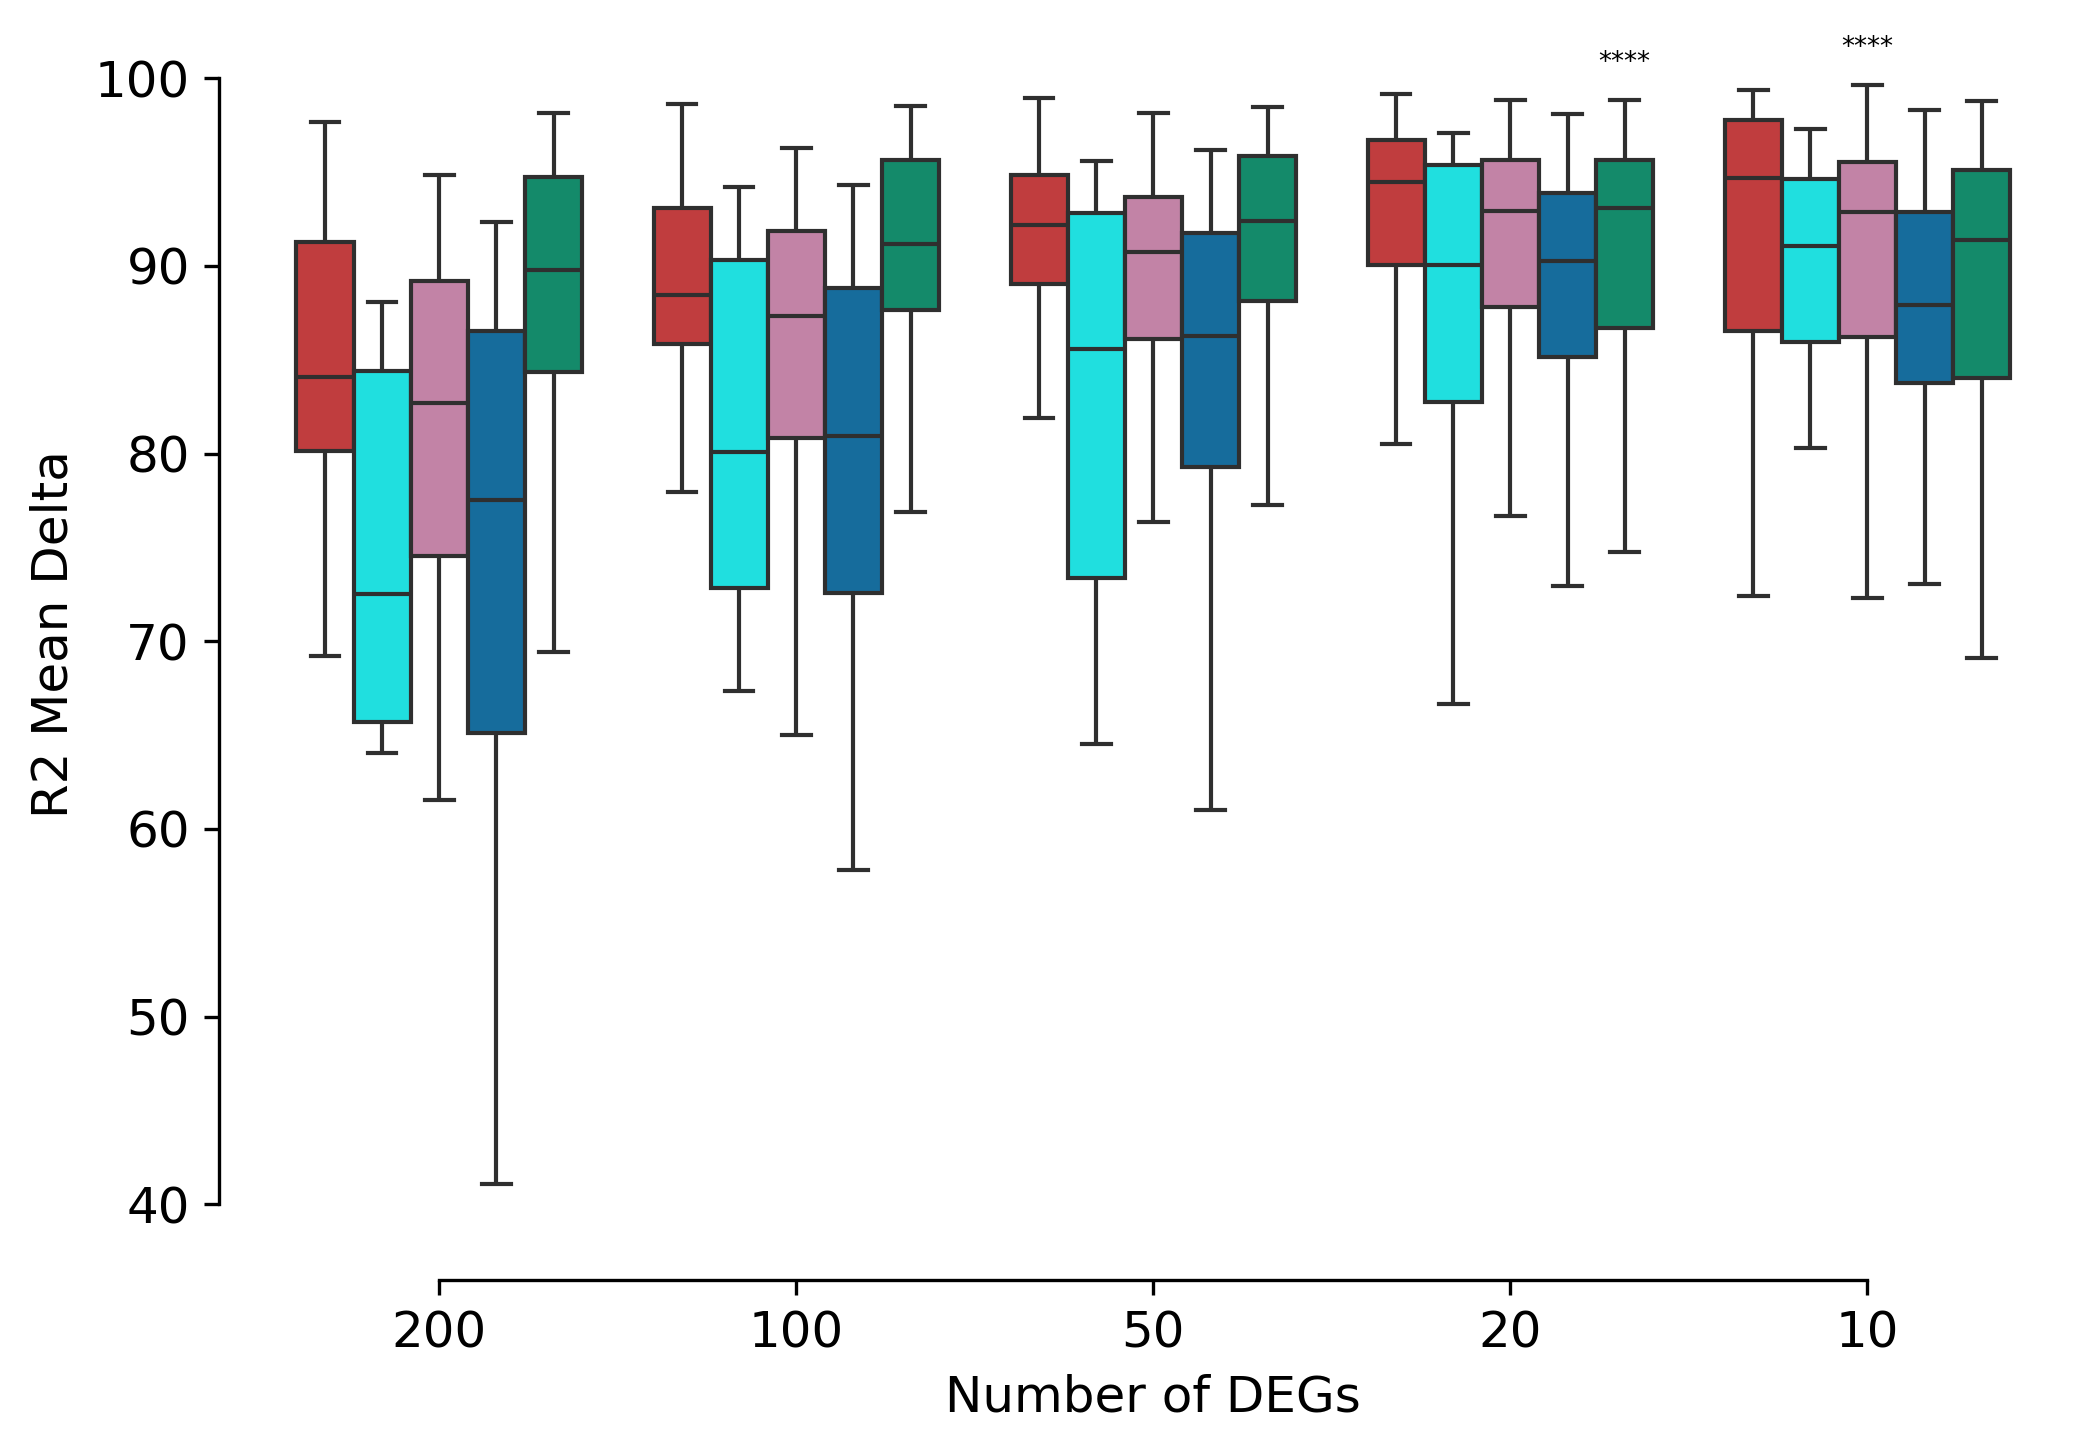

/tmp/claude-1001/-data-SCDISENTANGLE-CHECK/c8317c1e-44a6-4cad-a224-d698ddc8bd5c/scratchpad/REPRO_CLEAN/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


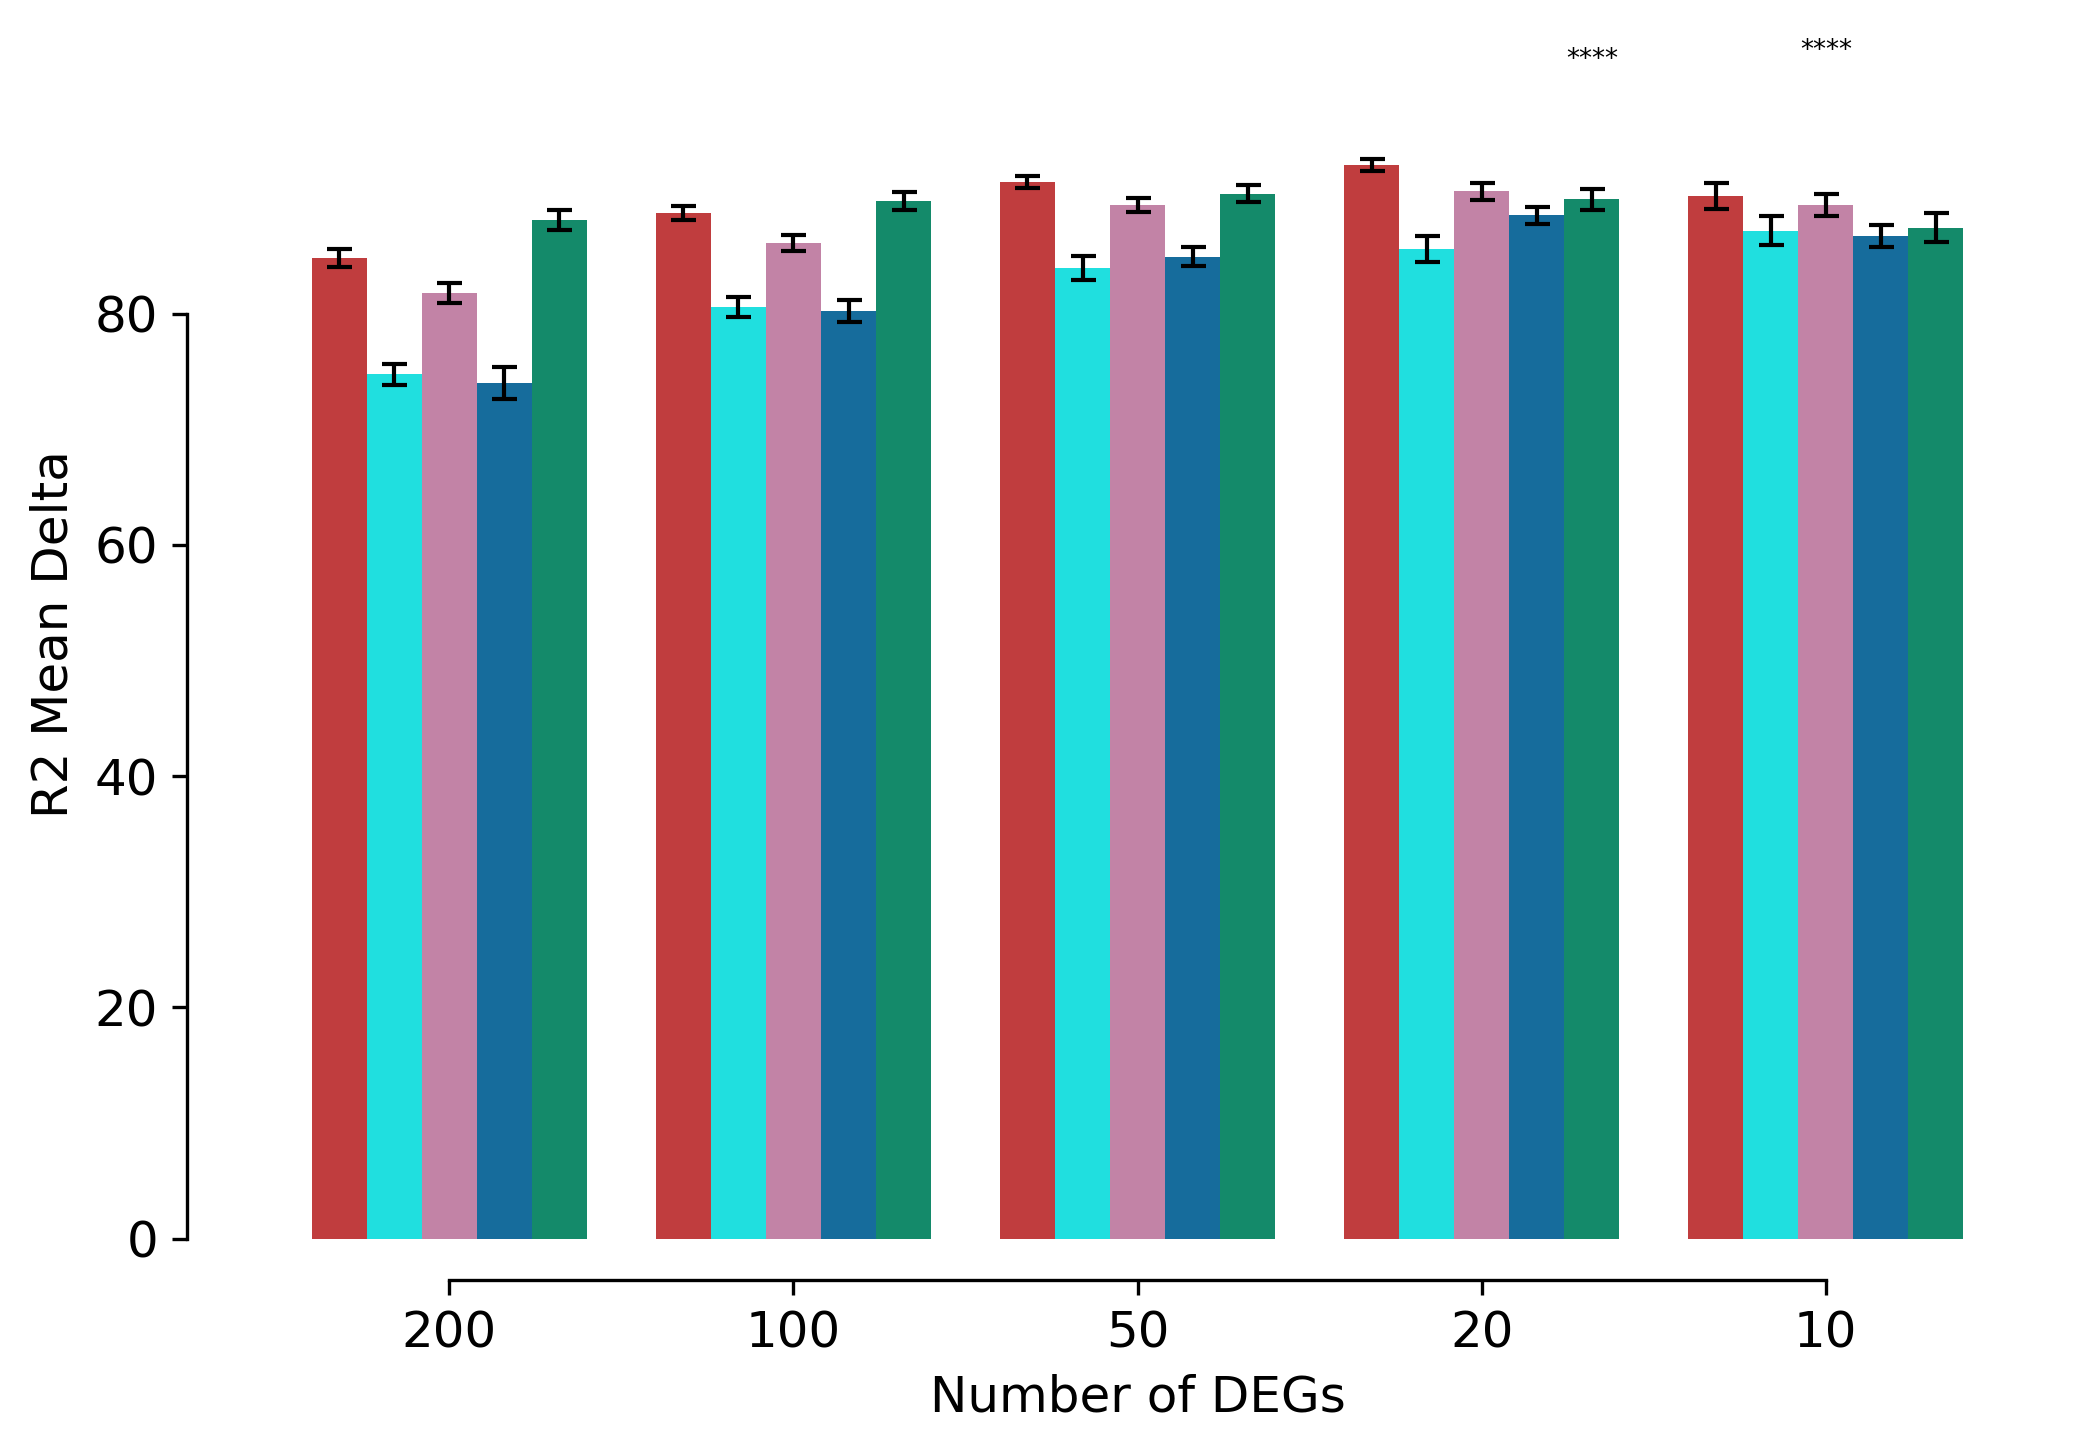

Using 100 perturbation


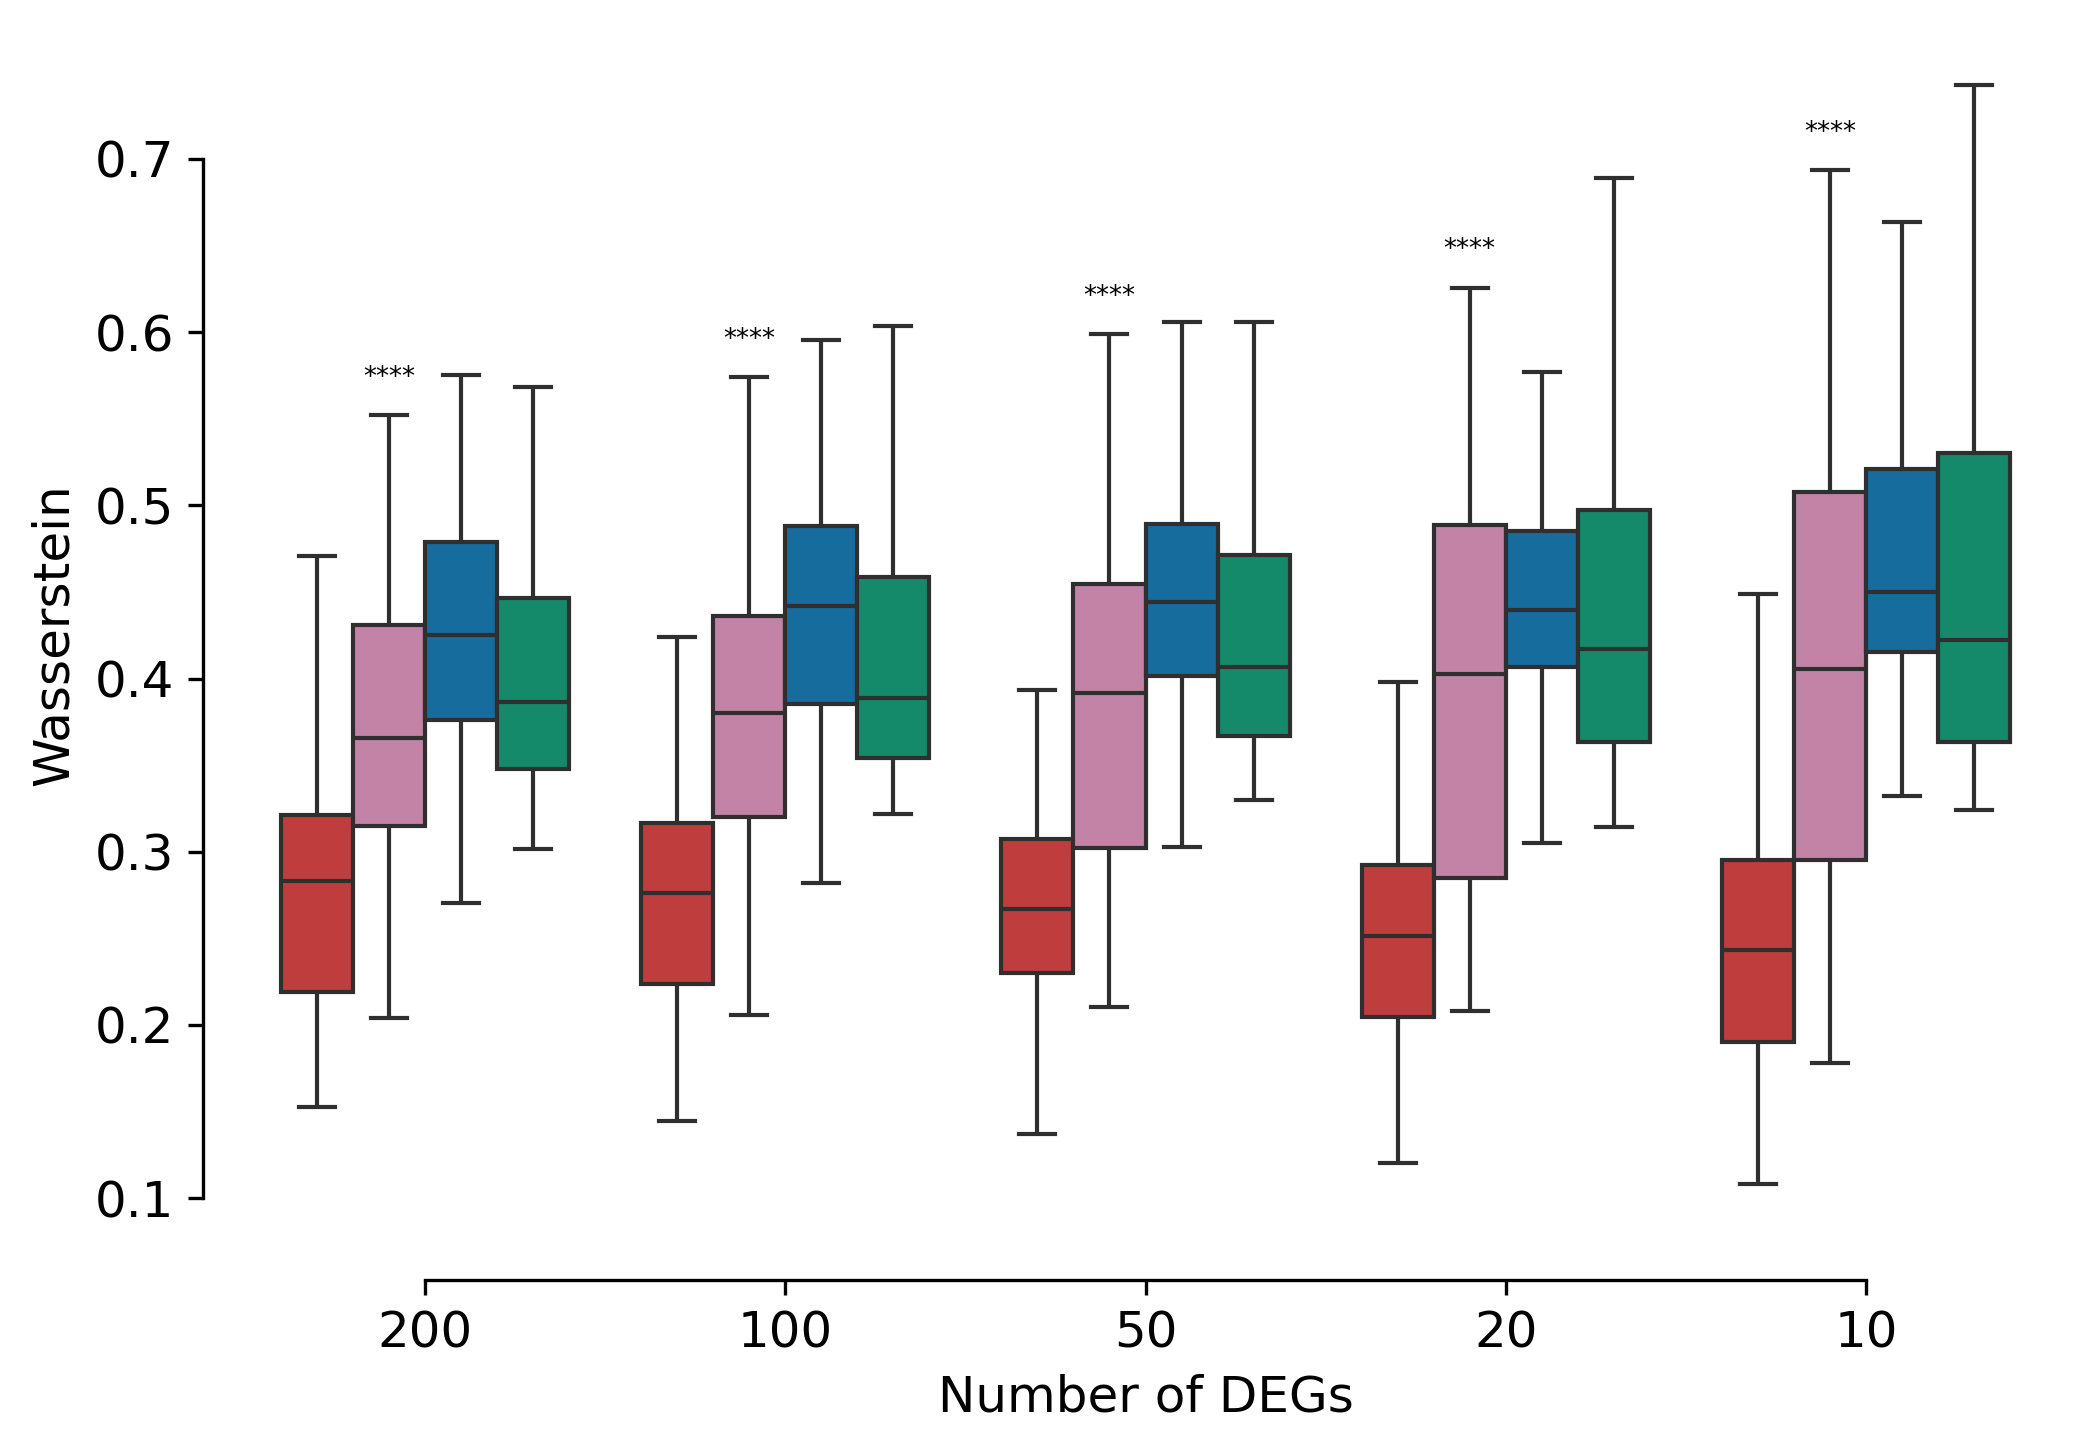

/tmp/claude-1001/-data-SCDISENTANGLE-CHECK/c8317c1e-44a6-4cad-a224-d698ddc8bd5c/scratchpad/REPRO_CLEAN/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


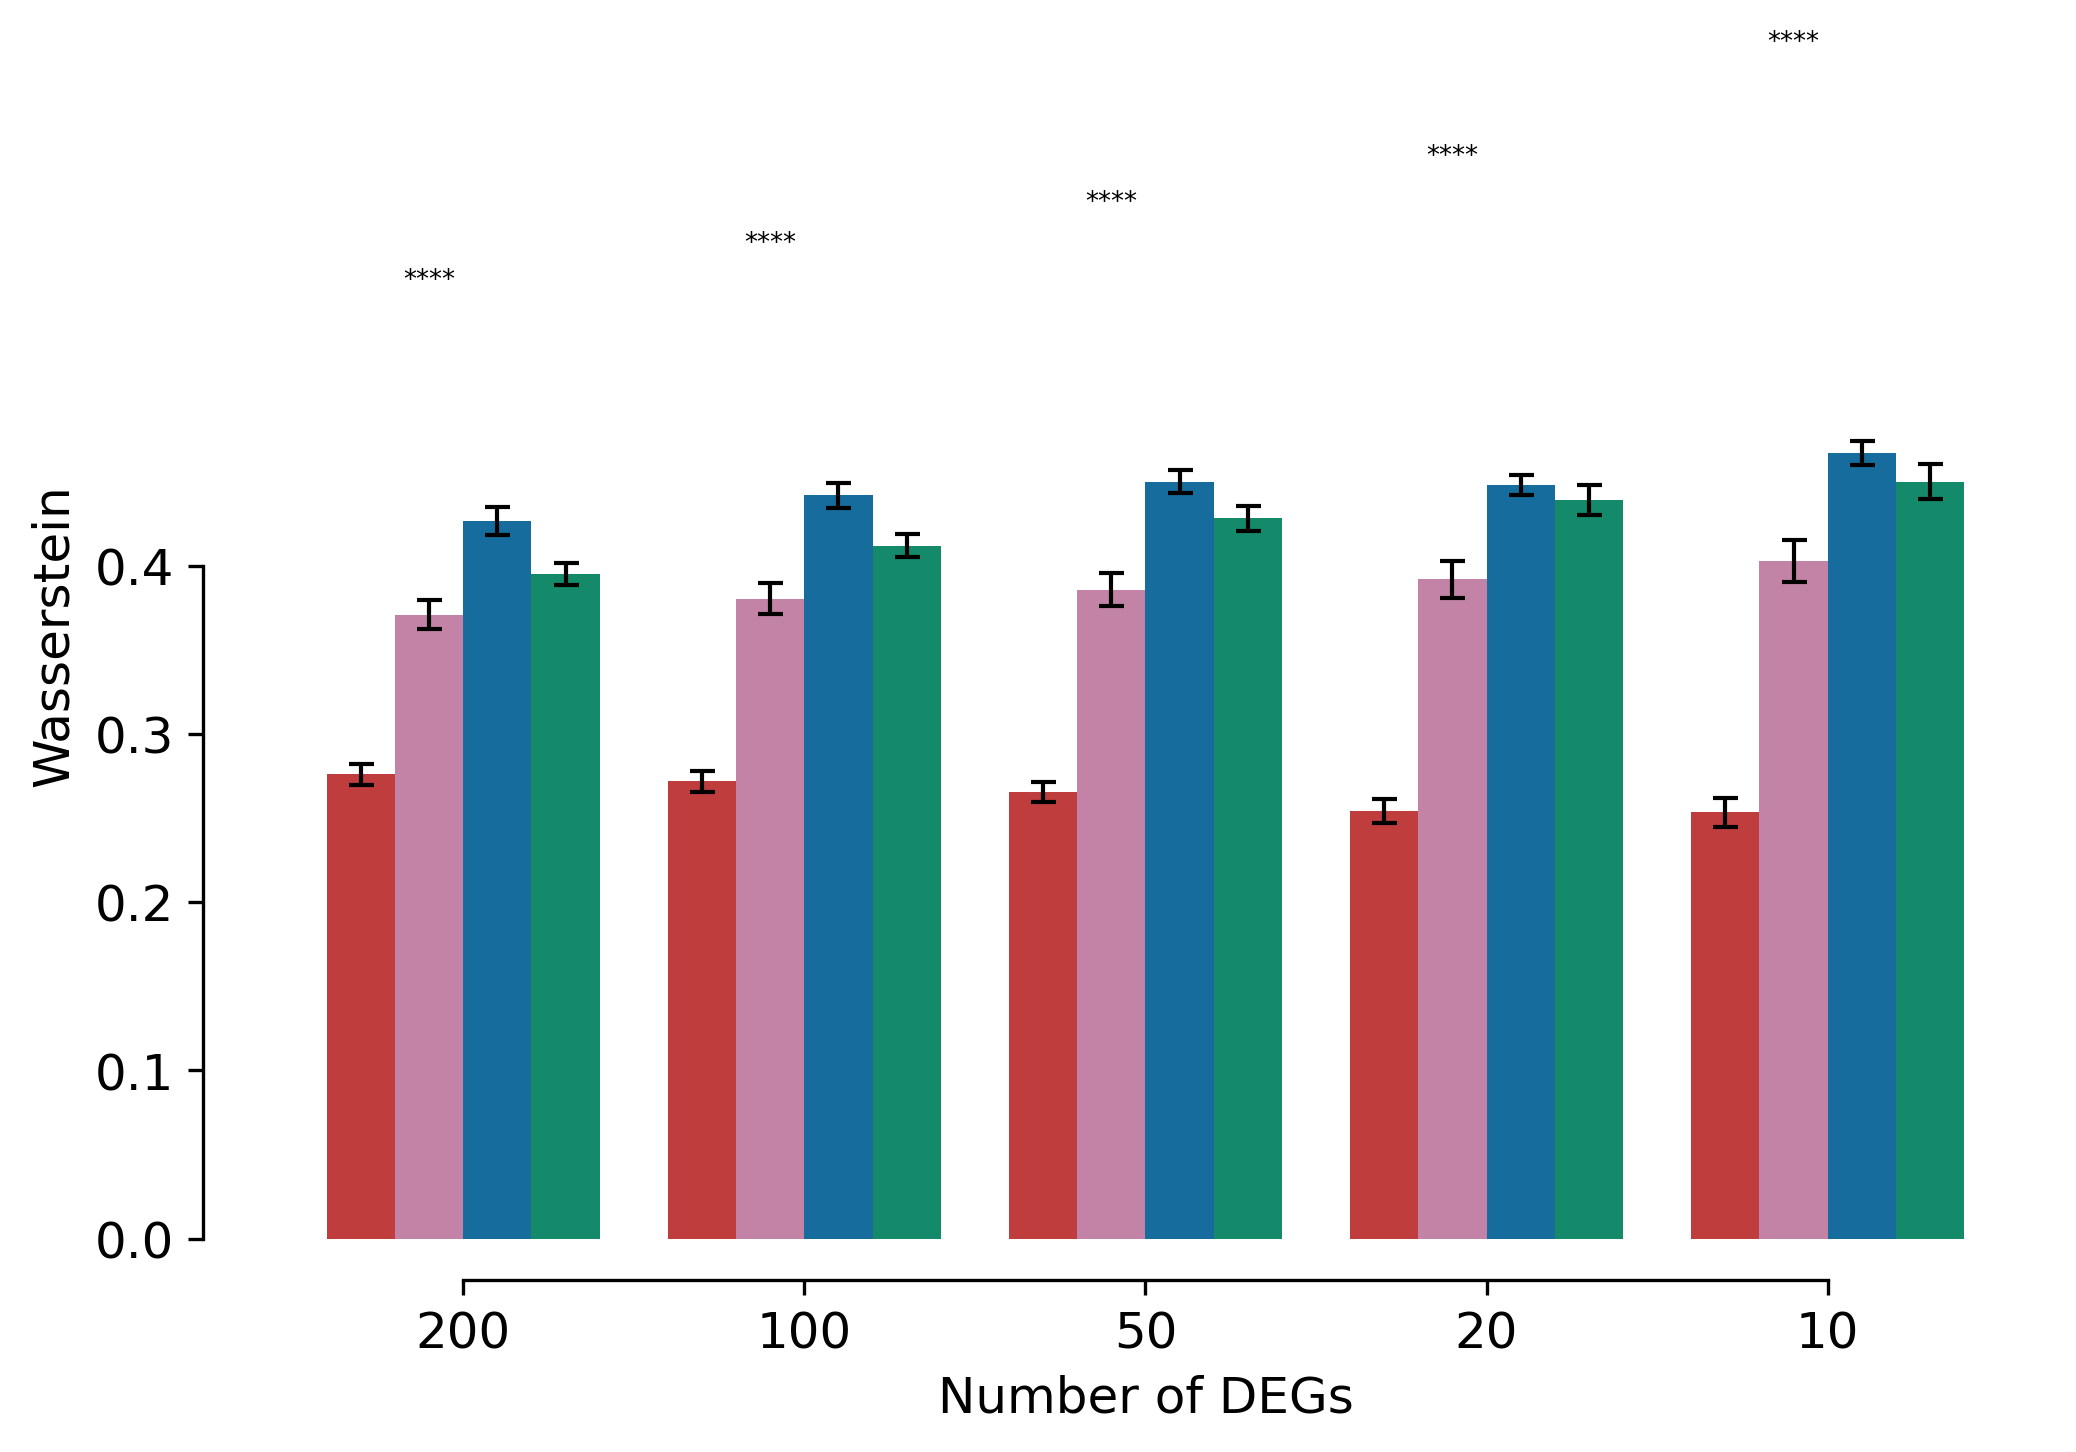

In [7]:
n_degs_list = ['200', '100', '50', '20', '10']

_colors = {
    'scDisentangle': '#d62728',
    'Context-agnostic': '#00FFFF', #'#698396',
    'Perturbation-agnostic': '#698396', #'#00FFFF',
    'CPA': '#CC79A7',
    'ScDisInFact': '#0072B2',
    'Biolord': '#009E73',
    
    }

_folder_paths = {
     'scDisentangle': f'{base_path}/SCDISENTANGLE/',
     'Context-agnostic': f'{base_path}/context-agnostic/',
     'Perturbation-agnostic': f'{base_path}/perturbation-agnostic/',
     'ScDisInFact': f'{base_path}/SCDISINFACT/',
     'CPA': f'{base_path}/CPA/',
     'Biolord': f'{base_path}/BIOLORD/',      
}

for metric_name in [
    'R2 Mean Delta', 'Wasserstein'
]:
        
    if metric_name not in ['R2 Mean' ,'R2 Mean Delta']:
        colors = {k:v for k,v in _colors.items() if not k in ['Perturbation-agnostic', 'Context-agnostic']}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in ['Perturbation-agnostic', 'Context-agnostic']}
    
    elif 'Delta' in metric_name:
        colors = {k:v for k,v in _colors.items() if not k == 'Perturbation-agnostic'}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k == 'Perturbation-agnostic'}
        
    else:
        colors = _colors
        folder_paths = _folder_paths
        
    metrics = mt.get_results(
        folder_paths, 
        metric_name=metric_name, 
        perts = all_results, 
        n_degs_list=n_degs_list
    )
    
    pvals, stars = mt.compute_pvalues_by_context(
        metrics_dict=metrics,
        metric_name=metric_name,
        run_ids=all_results,
        higher_is_better=None,
        anchor='scDisentangle'
    )
    
    records = hp.plot_data(
                metrics,
                plot_type='boxplot', 
                save_path=f'{FIG_ROOT}/{data_name}/Benchmarks/{metric_name}_box',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars
            )
    
    records = hp.plot_data(
                metrics,
                plot_type='barplot', 
                save_path=f'{FIG_ROOT}/{data_name}/Benchmarks/{metric_name}_bar',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars
            )